In [173]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

count = 0

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        count += 1

        if count == 5:
            break

    if count == 5:
        break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Late_blight/081d1e25-3f06-46a1-95ef-d10a62faa80f___GHLB2 Leaf 8600_final_masked.jpg
/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Late_blight/e6703c22-86f7-4bdf-9733-072180761976___RS_Late.B 5522_final_masked.jpg
/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Late_blight/9f946f43-424a-41be-9f91-b14fa3f2b37a___GHLB2 Leaf 8892_final_masked.jpg
/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Late_blight/dfc45d56-7ecb-46a5-b9da-9297df393f7b___RS_Late.B 6928_final_masked.jpg
/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented/Tomato___Late_blight/84b7d3ab-56ae-4eef-a852-7b32f3ef0160___GHLB2 Leaf 150_final_masked.jpg


In [174]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import cv2 

In [175]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [176]:
CONFIG = {
    "data_dir"   : "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
    "img_size"   : 224,
    "batch_size" : 32,
    "num_workers": 2,
    "seed"       : 42,
}
torch.manual_seed(CONFIG["seed"])

In [177]:
def compute_mean_std(data_dir, sample_limit=5000):
    """
    Compute per-channel mean and std from your dataset.
    """

    dataset = datasets.ImageFolder(
        data_dir,
        transform=transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor()
        ])
    )

    indices = torch.randperm(len(dataset))[:sample_limit]

    loader = DataLoader(
        torch.utils.data.Subset(dataset, indices),
        batch_size=64,
        num_workers=2
    )

    mean = torch.zeros(3)
    std = torch.zeros(3)
    n = 0

    for images, _ in loader:
        b = images.size(0)

        mean += images.mean(dim=[0, 2, 3]) * b
        std += images.std(dim=[0, 2, 3]) * b

        n += b

    mean /= n
    std /= n

    print(f"Dataset mean: {mean.tolist()}")
    print(f"Dataset std : {std.tolist()}")

    return mean.tolist(), std.tolist()



data_dir = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"



In [178]:
IMAGENET_MEAN, IMAGENET_STD = compute_mean_std(
    data_dir,
    sample_limit=5000
)

Dataset mean: [0.44012442231178284, 0.4763171970844269, 0.3739050030708313]
Dataset std : [0.19620409607887268, 0.17390702664852142, 0.21223728358745575]


In [179]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [180]:
def get_loaders(data_dir, val_split=0.2):
    full = datasets.ImageFolder(data_dir, transform=train_transforms)
    val_size   = int(len(full) * val_split)
    train_size = len(full) - val_size
    train_ds, val_ds = random_split(
        full, [train_size, val_size],
        generator=torch.Generator().manual_seed(CONFIG["seed"])
    )
    val_ds.dataset = datasets.ImageFolder(data_dir, transform=val_transforms)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                              shuffle=True,  num_workers=CONFIG["num_workers"],
                              pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
                              shuffle=False, num_workers=CONFIG["num_workers"],
                              pin_memory=True)
    return train_loader, val_loader, full.classes

In [181]:
def build_model_strategy_1(num_classes):
    """
    STRATEGY 1 — Feature Extraction
    Freeze everything. Only the new head trains.
    Use when: small dataset (<1k images) or quick baseline.
    Expected accuracy on PlantVillage: ~85-90% in 5 epochs.
    """
    
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
 
    
    for param in model.parameters():
        param.requires_grad = False
 
    in_features = model.fc.in_features   
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
   
    return model
 
 
def build_model_strategy_2(num_classes):
    """
    STRATEGY 2 — Partial Fine-tuning  ← WE USE THIS TODAY
    Freeze early layers, unfreeze layer4 (deepest residual block).
    Use when: medium dataset (1k-10k images) — our case with PlantVillage.
    Expected accuracy: ~96-98% in 10 epochs.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
 
  
    for param in model.parameters():
        param.requires_grad = False
 
   
    for param in model.layer4.parameters():
        param.requires_grad = True
 
    
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    frozen, trainable = 0, 0
    for p in model.parameters():
        if p.requires_grad:
            trainable += p.numel()
        else:
            frozen += p.numel()
    total = frozen + trainable
    print(f"\nStrategy 2 — Partial fine-tuning")
    print(f"  Frozen params    : {frozen:,}  ({100*frozen/total:.1f}%)")
    print(f"  Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)")
 
    return model
 
 
def build_model_strategy_3(num_classes):
    """
    STRATEGY 3 — Full Fine-tuning
    Unfreeze everything. Use a very small LR to avoid destroying
    the pretrained weights (catastrophic forgetting).
    Use when: large dataset (>10k images) AND domain is very different
    from ImageNet (e.g. medical X-rays, satellite images).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
 
   
 
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model
 

In [182]:

def get_optimizer_differential_lr(model):
    """
    Three learning rate groups:
      - Backbone early layers : lr = 1e-5  (barely move)
      - layer4 (last block)   : lr = 1e-4  (moderate update)
      - New classifier head   : lr = 1e-3  (learn fast)
    """
    backbone_params = []
    layer4_params   = []
    head_params     = []
 
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue  
        if "layer4" in name:
            layer4_params.append(param)
        elif "fc" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
 
    param_groups = [
        {"params": backbone_params, "lr": 1e-5},   
        {"params": layer4_params,   "lr": 1e-4},  
        {"params": head_params,     "lr": 1e-3},   
    ]
 
    optimizer = optim.Adam(param_groups, weight_decay=1e-4)
    return optimizer
 

In [183]:
import tqdm as tqdm
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm.tqdm(loader, desc="Training...."):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total
 
 
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm.tqdm(loader, desc="Evaluating..."):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total
 
 
def run_training(model, train_loader, val_loader,
                 use_differential_lr=True, num_epochs=10,
                 base_lr=1e-3, checkpoint_name="best.pth"):
 
    criterion = nn.CrossEntropyLoss()
 
    if use_differential_lr:
        
        optimizer = get_optimizer_differential_lr(model)
    else:
    
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=base_lr, weight_decay=1e-4
        )
 
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
 
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
    best_acc = 0.0
 
    
    print(f"  Training — {num_epochs} epochs")
    
 
    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = validate(model, val_loader, criterion)
        scheduler.step()
 
        for k, v in zip(history, [t_loss, t_acc, v_loss, v_acc]):
            history[k].append(v)
 
        lrs = [g["lr"] for g in optimizer.param_groups]
        lr_str = " | ".join([f"{lr:.2e}" for lr in lrs])
        print(f"Ep {epoch:2d}/{num_epochs}  "
              f"Train {t_acc:.2f}%  Val {v_acc:.2f}%  "
              f"LR: [{lr_str}]")
 
        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model.state_dict(), checkpoint_name)
            print(f"  ✓ Best val acc: {best_acc:.2f}% → saved")
 
    print(f"\nFinal best val accuracy: {best_acc:.2f}%")
    return history

In [184]:
#GRAD-CAM
class GradCAM:
    def __init__(self, model, target_layer):
        """
        model        : your trained ResNet
        target_layer : the conv layer to visualize
                       (use model.layer4[-1] for ResNet last block)
        """
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
 
        
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
 
    def _save_activation(self, module, input, output):
       
        self.activations = output.detach()
 
    def _save_gradient(self, module, grad_input, grad_output):
        
        self.gradients = grad_output[0].detach()
 
    def generate(self, image_tensor, class_idx=None):
        """
        image_tensor : [1, 3, 224, 224] normalized image
        class_idx    : which class to visualize (None = argmax)
        Returns      : heatmap as numpy array [0, 1], same HW as input
        """
        self.model.eval()
        image_tensor = image_tensor.to(device).requires_grad_(True)
 
      
        output = self.model(image_tensor)  
 
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
 
       
        self.model.zero_grad()
        output[0, class_idx].backward()  
 
        
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
 
      
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
 
        return cam, class_idx
 
    @staticmethod
    def overlay(image_tensor, cam, alpha=0.5):
        """
        Blend the Grad-CAM heatmap over the original image.
        Returns an RGB image as numpy array for plt.imshow().
        """
      
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img  = (image_tensor.squeeze().cpu() * std + mean).clamp(0, 1)
        img  = img.permute(1, 2, 0).numpy()  # [H, W, 3]
 
       
        cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
 
      
        heatmap = cv2.applyColorMap(
            (cam_resized * 255).astype(np.uint8),
            cv2.COLORMAP_JET
        )
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
 
       
        overlay = alpha * heatmap + (1 - alpha) * img
        return np.clip(overlay, 0, 1)
 
 
def visualize_gradcam(model, val_loader, class_names, n_samples=4):
    """
    Show Grad-CAM for n_samples from the validation set.
    For each sample: original | Grad-CAM overlay | prediction label.
    """
    gradcam = GradCAM(model, model.layer4[-1])
 
    images, labels = next(iter(val_loader))
    images = images[:n_samples]
    labels = labels[:n_samples]
 
    fig, axes = plt.subplots(2, n_samples, figsize=(4 * n_samples, 8))
    fig.suptitle("Top: original | Bottom: Grad-CAM (what the model looks at)",
                 fontsize=12)
 
    for i in range(n_samples):
        img = images[i].unsqueeze(0)
        cam, pred_idx = gradcam.generate(img)
        overlay = GradCAM.overlay(images[i].unsqueeze(0), cam)
 
       
        mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD).view(3,1,1)
        orig = (images[i] * std + mean).clamp(0,1).permute(1,2,0).numpy()
 
        true_cls = class_names[labels[i]][:25]
        pred_cls = class_names[pred_idx][:25]
        color    = "green" if labels[i] == pred_idx else "red"
 
        axes[0, i].imshow(orig)
        axes[0, i].set_title(f"True: {true_cls}", fontsize=8)
        axes[0, i].axis("off")
 
        axes[1, i].imshow(overlay)
        axes[1, i].set_title(f"Pred: {pred_cls}", fontsize=8, color=color)
        axes[1, i].axis("off")
 
    plt.tight_layout()
    plt.show()
    print("Grad-CAM saved to gradcam_visualization.png")


Classes: 38

Strategy 2 — Partial fine-tuning
  Frozen params    : 8,543,296  (34.8%)
  Trainable params : 16,033,318  (65.2%)
  Training — 10 epochs


Evaluating...: 100%|██████████| 340/340 [00:43<00:00,  7.79it/s]


Ep  1/10  Train 91.81%  Val 98.08%  LR: [9.76e-06 | 9.76e-05 | 9.76e-04]
  ✓ Best val acc: 98.08% → saved


Evaluating...: 100%|██████████| 340/340 [00:36<00:00,  9.36it/s]


Ep  2/10  Train 97.57%  Val 98.72%  LR: [9.05e-06 | 9.05e-05 | 9.05e-04]
  ✓ Best val acc: 98.72% → saved


...

Ep  8/10  Train 99.63%  Val 99.50%  LR: [9.55e-07 | 9.55e-06 | 9.55e-05]
  ✓ Best val acc: 99.50% → saved


Evaluating...: 100%|██████████| 340/340 [00:36<00:00,  9.35it/s]


Ep  9/10  Train 99.76%  Val 99.56%  LR: [2.45e-07 | 2.45e-06 | 2.45e-05]
  ✓ Best val acc: 99.56% → saved


Evaluating...: 100%|██████████| 340/340 [00:36<00:00,  9.35it/s]


Ep 10/10  Train 99.77%  Val 99.62%  LR: [0.00e+00 | 0.00e+00 | 0.00e+00]
  ✓ Best val acc: 99.62% → saved

Final best val accuracy: 99.62%


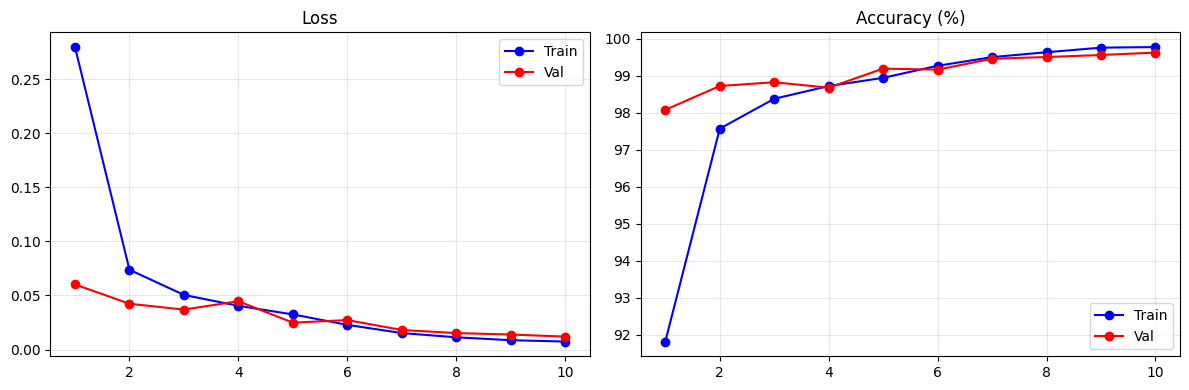

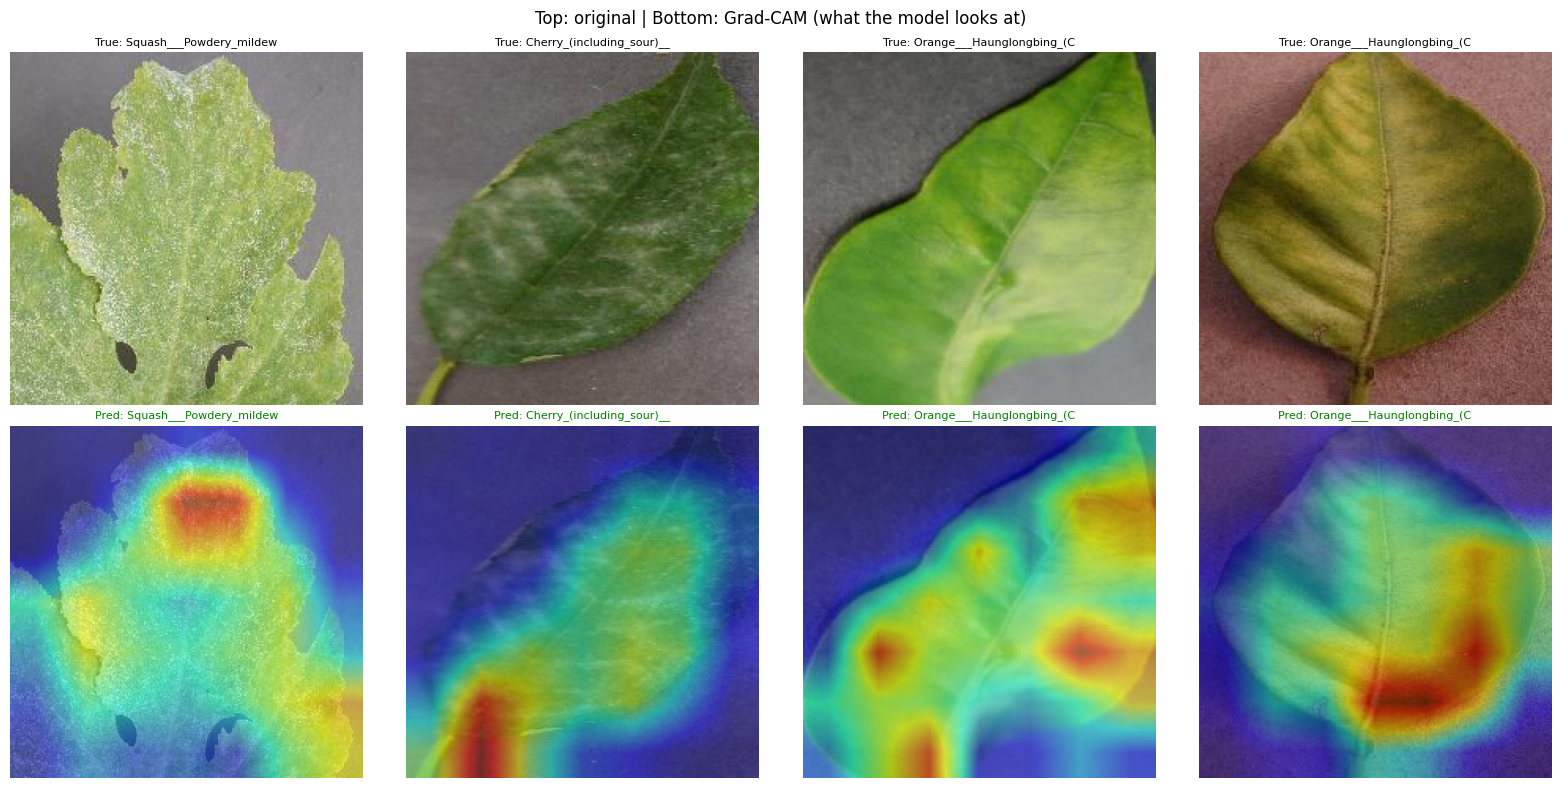

Grad-CAM saved to gradcam_visualization.png


In [185]:
if __name__ == "__main__":
 
    train_loader, val_loader, class_names = get_loaders(CONFIG["data_dir"])
    num_classes = len(class_names)
    print(f"Classes: {num_classes}")
 
    
    model = build_model_strategy_2(num_classes).to(device)
 
   
    history = run_training(
        model, train_loader, val_loader,
        use_differential_lr=True,
        num_epochs=10,
        checkpoint_name="resnet50_plantvillage.pth"
    )
 
   
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history["train_loss"], "b-o", label="Train")
    ax1.plot(epochs, history["val_loss"],   "r-o", label="Val")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, history["train_acc"], "b-o", label="Train")
    ax2.plot(epochs, history["val_acc"],   "r-o", label="Val")
    ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("transfer_learning_curves.png", dpi=150)
    plt.show()
 
  
    model.load_state_dict(torch.load("resnet50_plantvillage.pth"))
    visualize_gradcam(model, val_loader, class_names, n_samples=4)
 
 